# Tool catalog: attach an exact image

Run this notebook in a disposable JupyterLab project with its live Python kernel and selected ChatGPT connection. It creates a blue PNG, shows it, and binds its exact path and SHA-256 to one question only after you click **Attach image**. The AI tool question below also asks for an explicit confirmation; neither the call nor the click runs the target question. Inspect each receipt after the visible operation completes, then run the image question yourself.


## Create a disposable still-image reference

Generated blue PNG: browser-media-attachment-db77ab223faa4541babe7fd719fcf7f1.png b35ff24aed6413b07f72b30c35c05d73379d4491cbb533565ab78e0add7e3332


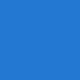

In [1]:
from pathlib import Path
from uuid import uuid4
import hashlib
from PIL import Image
from IPython.display import display
from nbinlineai.tools import attach_media, operation_status

server_root = Path.cwd().resolve()
source_path = server_root / f'browser-media-attachment-{uuid4().hex}.png'
Image.new('RGB', (2, 2), (35, 120, 210)).save(source_path, format='PNG')
source_ref = {'path': source_path.name, 'sha256': hashlib.sha256(source_path.read_bytes()).hexdigest()}
print('Generated blue PNG:', source_path.name, source_ref['sha256'])
display(Image.open(source_path).resize((80, 80)))


Use &`attach_media` with media=$`source_ref`, `question_cell_id='attachment-question'`, and `detail='auto'`. Report its immediate operation ID and waiting/running state, then ask me to click **Attach image**. Do not claim confirmation or run the target question yet.


Operation `6g9-1PR2Hok1U-K8IddRrvOb165_0RhJ` is waiting for your confirmation. Please click **Attach image**. I haven’t run the target question.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `attach_media` | receipt accepted | {"media":{"path":"browser-media-attachment-db77ab223faa4541babe7fd719fcf7f1.png","sha256":"b35ff24aed6413b07f72b30c35c05d73379d4491cbb533565ab78e0add7e3332"},"question_cell_id":"attachment-question","detail":"auto"} | {"operation_id":"6g9-1PR2Hok1U-K8IddRrvOb165_0RhJ","status":"waiting_for_user"} |


After I click **Attach image**, use &`operation_status` on the preceding AI attachment operation ID. Report the actual terminal state, question ID, and exact image SHA-256 only if confirmed; otherwise stop and retry later. Do not run the target question for me.


Confirmed: operation `6g9-1PR2Hok1U-K8IddRrvOb165_0RhJ` completed. Question ID: `attachment-question`. Image SHA-256: `b35ff24aed6413b07f72b30c35c05d73379d4491cbb533565ab78e0add7e3332`. I did not run the target question.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"6g9-1PR2Hok1U-K8IddRrvOb165_0RhJ"} | {"operation_id":"6g9-1PR2Hok1U-K8IddRrvOb165_0RhJ","status":"completed","result":{"confirmed":true,"question_cell_id":"attachment-question","image_sha256":"b35ff24aed6413b07f72b30c35c05d73379d4491cbb533565ab78e0add7e3332","detail":"auto"}} |


## attach_media — confirm the image for this question

Run the next code cell, then inspect its receipt in the following cell. Click **Attach image** in the visible confirmation. The receipt first reports `waiting_for_user`; after the click it reports `completed` with the exact SHA-256 and question ID. If you cancel, no attachment is recorded. Run the inspection cell again after the receipt changes.

In [2]:
from nbinlineai.tools import attach_media
attached = attach_media(source_ref, 'attachment-question', detail='auto')
attached

BrowserReceipt(operation_id=None, status='running')

In [3]:
attached.status, attached.operation_id, attached.result, attached.error

('completed',
 'jP-TC0W_wYPmNHlpGVOLvS-6CALa9n1P',
 {'confirmed': True,
  'question_cell_id': 'attachment-question',
  'image_sha256': 'b35ff24aed6413b07f72b30c35c05d73379d4491cbb533565ab78e0add7e3332',
  'detail': 'auto'},
 None)

## Run the confirmed image question

Open its context preview to check the image indicator. Preview does not run the model. Click Run on the question with the selected ChatGPT connection after the attachment receipt is complete; the model receives the image as a native image item. If the file or hash changes, confirm a new exact image instead of reusing an old attachment.


What color is the small square in my attached image? Please describe the visible color in one sentence.

## Remove the disposable source after the question

Keep the PNG until you have finished previewing and running the question. The saved attachment points to this exact path and hash; removing it makes a later preview or rerun fail closed. Run this cleanup cell only after you are done.

In [4]:
assert source_path.exists()
source_path.unlink()
print('Disposable image removed:', not source_path.exists())

Disposable image removed: True
